In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 
import numpy as np


In [3]:
df = pd.read_csv("../data/processed/tesla_stocks_cleaned.csv")

In [4]:
df.head()

,Date,Volume,Open,High,Low,Close,Intraday_change,day,month,year,Daily_Return,MA_7,MA_30,Volatility_7,is_quarter_end,Price_Range,target,Close_lag1,Close_lag2
0,2015-01-21,62161784,12.6367,13.2453,12.6340,13.1047,0.4680,21,1,2015,0.024181,13.072286,14.017067,0.026203,0,0.6113,13.4413,12.7953,12.8713
1,2015-01-22,61556264,13.1333,13.5493,13.0133,13.4413,0.3080,22,1,2015,0.025685,13.066657,13.988753,0.027814,0,0.5360,13.4193,13.1047,12.7953
2,2015-01-23,51615754,13.3527,13.5667,13.2220,13.4193,0.0666,23,1,2015,-0.001637,13.038457,13.954087,0.027451,0,0.3447,13.7700,13.4413,13.1047
3,2015-01-26,48466791,13.4553,13.9080,13.4033,13.7700,0.3147,26,1,2015,0.026134,13.170457,13.946777,0.014794,0,0.5047,13.7320,13.4193,13.4413
4,2015-01-27,41668869,13.6280,13.8687,13.5533,13.7320,0.1040,27,1,2015,-0.002760,13.304843,13.940333,0.014561,0,0.3154,13.2913,13.7700,13.4193


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

df['Intraday_change'] = df['Close'] - df['Open']
print(df['Intraday_change'].mean())

df['Daily_Return'] = df['Close'].pct_change()

df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

df['Volatility_7'] = df['Daily_Return'].rolling(window=7).std()

df['is_quarter_end'] = np.where(df['month']%3==0, 1, 0)

df['Price_Range'] = df['High'] - df['Low']

df['target'] = df['Close'].shift(-1)

df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)
df.head()

-0.018991475673502522


,Date,Volume,Open,High,Low,Close,Intraday_change,day,month,year,Daily_Return,MA_7,MA_30,Volatility_7,is_quarter_end,Price_Range,target,Close_lag1,Close_lag2
0,2015-01-21,62161784,12.6367,13.2453,12.6340,13.1047,0.4680,21,1,2015,NaN,NaN,NaN,NaN,0,0.6113,13.4413,NaN,NaN
1,2015-01-22,61556264,13.1333,13.5493,13.0133,13.4413,0.3080,22,1,2015,0.025685,NaN,NaN,NaN,0,0.5360,13.4193,13.1047,NaN
2,2015-01-23,51615754,13.3527,13.5667,13.2220,13.4193,0.0666,23,1,2015,-0.001637,NaN,NaN,NaN,0,0.3447,13.7700,13.4413,13.1047
3,2015-01-26,48466791,13.4553,13.9080,13.4033,13.7700,0.3147,26,1,2015,0.026134,NaN,NaN,NaN,0,0.5047,13.7320,13.4193,13.4413
4,2015-01-27,41668869,13.6280,13.8687,13.5533,13.7320,0.1040,27,1,2015,-0.002760,NaN,NaN,NaN,0,0.3154,13.2913,13.7700,13.4193


In [6]:
df.dropna(inplace=True)

In [7]:
df.head()
df.shape

(2457, 19)

In [8]:
df.to_csv("../data/processed/tesla_feature_engineered.csv", index=False)

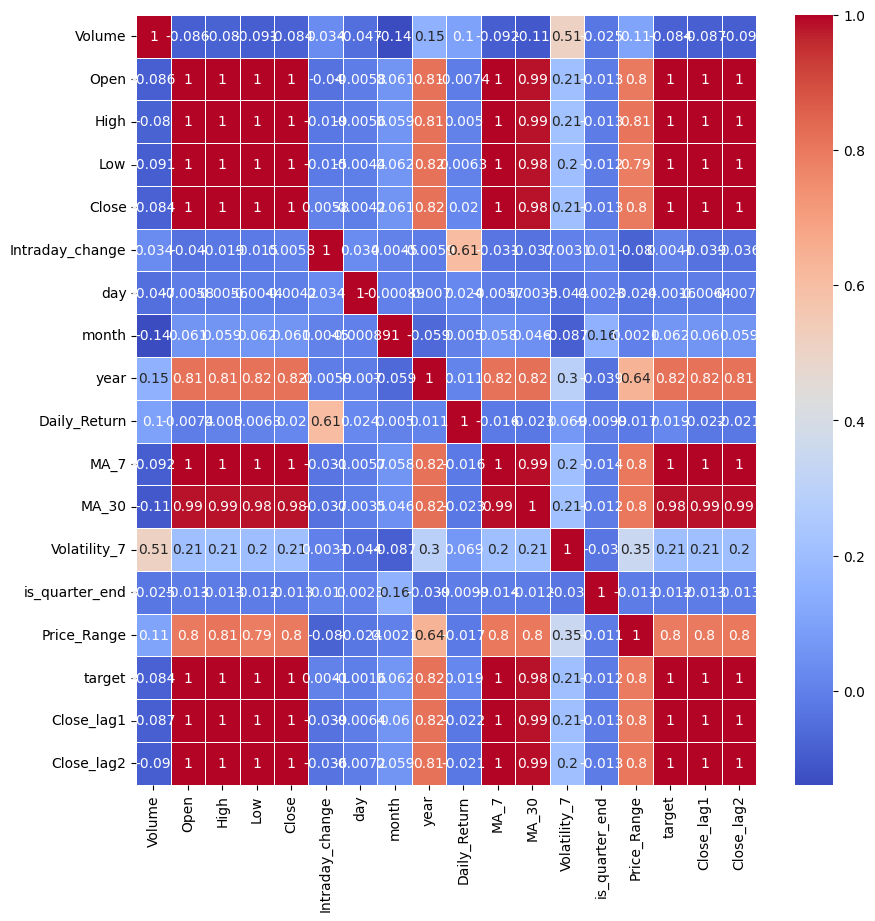

In [11]:
df.drop('Date', axis=1).groupby('is_quarter_end').mean() 
plt.figure(figsize=(10, 10)) 
sb.heatmap(df.drop('Date', axis=1).corr(), annot=True, cmap='coolwarm', linewidths=0.5) 
plt.show()

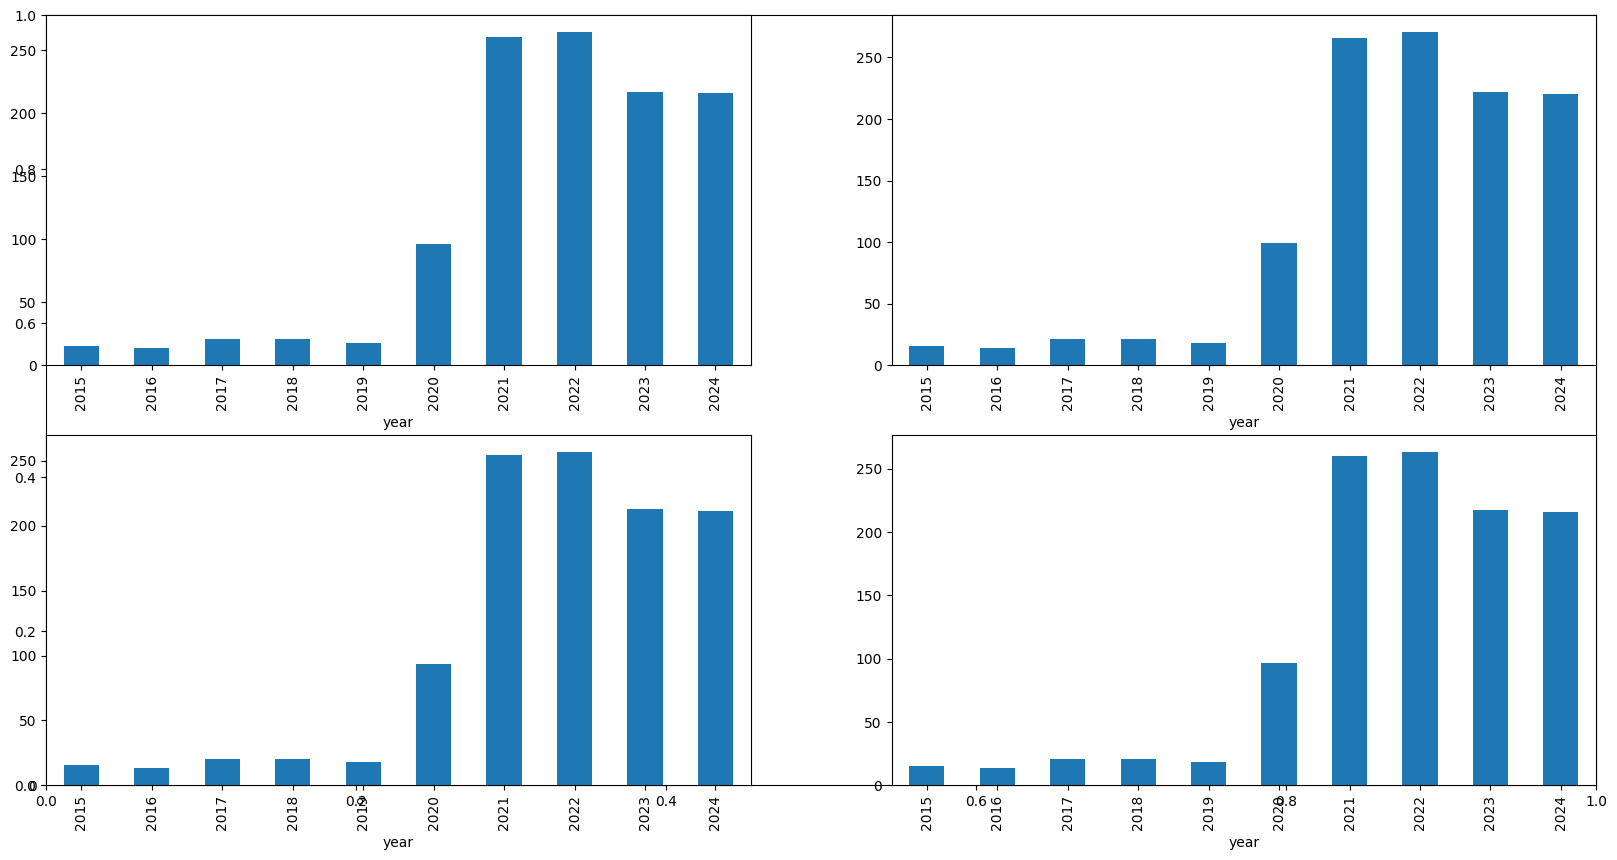

In [12]:
data_grouped = df.drop('Date', axis=1).groupby('year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()